# 04 analysis

Step 9 - mechanism: pool memorisation, and what the denoiser actually repairs.

## Настройка

In [1]:
%load_ext autoreload
%autoreload 2

import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from steering import corruptions, denoiser, hooks, io, spaces, vectors, metrics

MODEL, LAYER = "gpt2", 6
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL).eval().to(DEVICE)

sae = vectors.load_sae("gpt2-small-resid-post-v5-128k", "blocks.6.hook_resid_post",
                        layer=LAYER, d_model=768, device=DEVICE)
decoder = sae.W_dec.detach()
split = vectors.load_split(io.RESULTS / "feature_splits_gpt2.json")
center = spaces.should_center(MODEL)

prompts = json.loads((io.REPO_ROOT / "configs" / "prompts_neutral_32.json").read_text())["prompts"]
with hooks.ResidualHook(model, layer=LAYER, capture=True) as _h, torch.no_grad():
    model(**tokenizer(prompts, return_tensors="pt", padding=True).to(DEVICE))
scale = spaces.activation_scale(_h.captured[0], exclude_sink=True)

# Cache hit -- this is the exact config Step 4 already cached under, so cache_activations
# itself is never actually called here.
activations = io.run_or_load(
    "clean_activations_gpt2", {"model": "gpt2", "layer": LAYER, "n_docs": 3000,
                                "max_length": 64, "max_tokens": 200_000, "version": 1},
    lambda: (_ for _ in ()).throw(RuntimeError("cache miss -- rerun 02_train.ipynb's Step 4 cell")),
    where="artifacts",
)
N_VAL = 5000
val_activations, train_activations = activations[:N_VAL], activations[N_VAL:]
print(f"split DEV {len(split.dev)}, scale {scale:.1f}, center {center}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

cached  clean_activations_gpt2.pt  (6be99263c06aee12)
split DEV 35, scale 95.1, center True


## Шаг 9А. Поведение денойзера при обучении rank-1

In [2]:
dev_probe = corruptions.StructuredRank1(decoder, pool_indices=split.dev, holdout=set(),
                                        rho_min=0.05, rho_max=1.0)

POOL_SIZES = [64, 256, 1024, None]  # None = full pool = D4
STEPS, BATCH_SIZE, LR, SEED = 5000, 256, 1e-3, 0

import pandas as pd

mem_rows = io.run_or_load(
    "pool_memorization_curve_gpt2",
    {"pool_sizes": [str(p) for p in POOL_SIZES], "steps": STEPS, "batch_size": BATCH_SIZE,
     "lr": LR, "seed": SEED, "split_fingerprint": split.fingerprint(), "version": 1},
    lambda: pd.DataFrame(denoiser.pool_memorization_curve(
        train_activations, val_activations, decoder, split, dev_probe,
        pool_sizes=POOL_SIZES, d_model=768, activation_scale=scale, center=center,
        steps=STEPS, batch_size=BATCH_SIZE, lr=LR, seed=SEED, device=DEVICE,
    )),
)
print(mem_rows)

cached  pool_memorization_curve_gpt2.csv  (0fabf352934f745d)
  pool_size  n_directions  own_loss  unseen_loss  memorization_ratio
0        64            64  0.005099     0.168250           32.997566
1       256           256  0.019951     0.157501            7.894499
2      1024          1024  0.120540     0.118651            0.984332
3      full        130967  0.198805     0.120651            0.606884


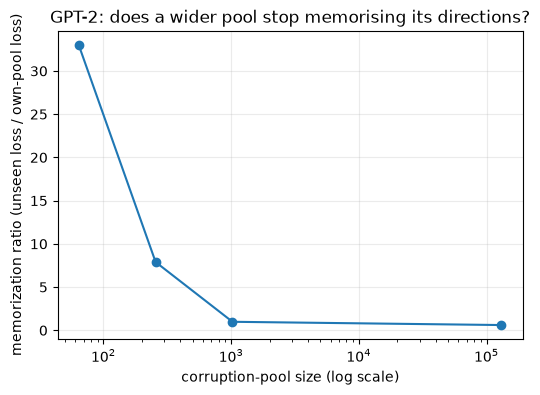

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mem_rows["n_directions"], mem_rows["memorization_ratio"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("corruption-pool size (log scale)")
ax.set_ylabel("memorization ratio (unseen loss / own-pool loss)")
ax.set_title("GPT-2: does a wider pool stop memorising its directions?")
ax.grid(alpha=0.25)

io.FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(io.FIGURES / "pool_memorization_gpt2.png", dpi=150, bbox_inches="tight")
plt.show()

## Шаг 9B. Действие денойзера.

In [6]:
D4 = denoiser.load_denoiser(io.ARTIFACTS / "denoiser_d4_seed0.pt", device=DEVICE)
corruption_desc = torch.load(io.ARTIFACTS / "denoiser_d4_seed0.pt", map_location="cpu",
                             weights_only=False)["extra"]["corruption"]

pca_fit = metrics.fit_pca_distance(train_activations).to(DEVICE)
print(f"clean-distribution PCA fit on {train_activations.shape[0]} activations")

clean-distribution PCA fit on 181699 activations


In [7]:
N_CLEAN = 500
clean_sample = val_activations[:N_CLEAN].to(DEVICE)
pca_dist_clean_mean = pca_fit.distance(clean_sample).mean().item()
R_GRID = [0.2, 0.4, 0.6, 0.8, 1.0]  # r=0 has nothing to denoise

rows = []
for feature_id in split.test:
    v = decoder[feature_id].to(DEVICE)
    v_hat = v / v.norm()
    for r in R_GRID:
        steered = clean_sample + r * scale * v_hat
        t = corruptions.t_for_r(corruption_desc, r)
        denoised = D4(steered, t=t)
        corr = metrics.denoiser_correction_along_v(D4, steered, v, t=t)
        rows.append({
            "feature_id": feature_id, "r": r,
            "pca_dist_clean": pca_dist_clean_mean,
            "pca_dist_steered": pca_fit.distance(steered).mean().item(),
            "pca_dist_denoised": pca_fit.distance(denoised).mean().item(),
            "along_v_mean": corr["along_v"].mean().item(),
            "fraction_along_v_mean": corr["fraction_along_v"].mean().item(),
        })

mech_df = pd.DataFrame(rows)
io.run_or_load("denoiser_repair_mechanism_gpt2",
               {"n_clean": N_CLEAN, "r_grid": R_GRID, "split_fingerprint": split.fingerprint(),
                "checkpoint": "denoiser_d4_seed0", "version": 1},
               lambda: mech_df)
print(mech_df.groupby("r")[["pca_dist_steered", "pca_dist_denoised", "fraction_along_v_mean"]].mean())

computed denoiser_repair_mechanism_gpt2.csv  (7407f8ba64d84dcc)
     pca_dist_steered  pca_dist_denoised  fraction_along_v_mean
r                                                              
0.2         30.137197          28.710672               0.029162
0.4         35.537945          25.766388               0.294907
0.6         42.973217          24.152939               0.488152
0.8         51.565339          22.395448               0.617300
1.0         60.831770          22.885260               0.705053


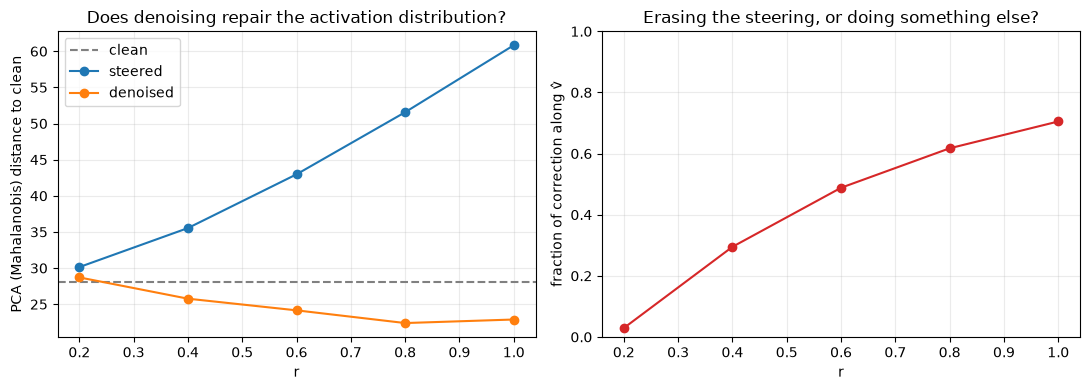

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

agg = mech_df.groupby("r")[["pca_dist_steered", "pca_dist_denoised"]].mean()
axes[0].axhline(pca_dist_clean_mean, color="gray", linestyle="--", label="clean")
axes[0].plot(agg.index, agg["pca_dist_steered"], marker="o", label="steered")
axes[0].plot(agg.index, agg["pca_dist_denoised"], marker="o", label="denoised")
axes[0].set_xlabel("r"); axes[0].set_ylabel("PCA (Mahalanobis) distance to clean")
axes[0].set_title("Does denoising repair the activation distribution?")
axes[0].legend(); axes[0].grid(alpha=0.25)

frac = mech_df.groupby("r")["fraction_along_v_mean"].mean()
axes[1].plot(frac.index, frac.values, marker="o", color="tab:red")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("r"); axes[1].set_ylabel("fraction of correction along v̂")
axes[1].set_title("Erasing the steering, or doing something else?")
axes[1].grid(alpha=0.25)

fig.tight_layout()
io.FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(io.FIGURES / "mechanism_repair_gpt2.png", dpi=150, bbox_inches="tight")
plt.show()